# 07 — Paper Figures (from exports)

Builds the **final thesis figures** exclusively from the `.npz` files in
`results/` (written by notebooks 01–06). No raw data, no reprocessing — the
same pattern as `paper_plots_from_exports.ipynb`.

Rules:
- **No titles on figures** — `paper.caption_note(...)` prints the caption
  text below the cell instead.
- All cosmetic control in one place: `paper.STYLE` (global) +
  `paper.style_axis(ax, xlabel=…, xlim=…, ylim=…)` per axis.
- `paper.save_paper_fig(fig, 'name')` writes PNG + PDF to `Figures_paper/`.

Prerequisite exports:

| File | From notebook |
|---|---|
| `geometry_sag.npz` | 01 |
| `timedomain_example.npz` | 02 |
| `freqdomain_eta.npz`, `freqdomain_frf.npz` | 03 |
| `amplitude_reference.npz`, `asymmetry.npz` | 04 |
| `modal_summary.npz` | 05 |
| `linearity_eta.npz` | 06 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%load_ext autoreload
%autoreload 2

from ldv_analysis import paper
from ldv_analysis.export import load_results, list_exports
from ldv_analysis.config import CABLE_COLORS, GAP_MARKERS

# Global style — tweak here (sizes, fonts, output formats) and re-run all.
paper.apply_paper_style({
    # 'label_fs': 11,
    # 'formats': ('png', 'pdf', 'svg'),
})

list_exports()

  amplitude_reference.npz             exported 2026-07-15T00:19:08
  asymmetry.npz                       exported 2026-07-15T00:19:08
  freqdomain_eta.npz                  exported 2026-07-15T00:17:58
  freqdomain_frf.npz                  exported 2026-07-15T00:17:59
  geometry_sag.npz                    exported 2026-07-15T00:15:11
  linearity_eta.npz                   exported 2026-07-15T10:19:10
  modal_summary.npz                   exported 2026-07-15T10:16:28
  timedomain_example.npz              exported 2026-07-15T00:16:07


[WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/amplitude_reference.npz'),
 WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/asymmetry.npz'),
 WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/freqdomain_eta.npz'),
 WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/freqdomain_frf.npz'),
 WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/geometry_sag.npz'),
 WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/linearity_eta.npz'),
 WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS GmbH/Dokumente/Master_Thesis/Experiment2/Analysis_v2/results/modal_summary.npz'),
 WindowsPath('C:/Users/ocornelius/OneDrive - IMENSUS

---
## Fig. A — η vs Θ (all configurations)

Coherence-gated quasi-static band mean of |H_η| against the sag-based Θ,
with the analytical curve η = 1/(1+Θ). Colour = cable, marker = gap,
open = intended-sag variant.

saved: eta_vs_theta.png, eta_vs_theta.pdf
[caption] Measured quasi-static strain-transfer efficiency (band 1-25 Hz, coherence-gated H1 estimate) against the sag parameter Theta, with the analytical prediction 1/(1+Theta).


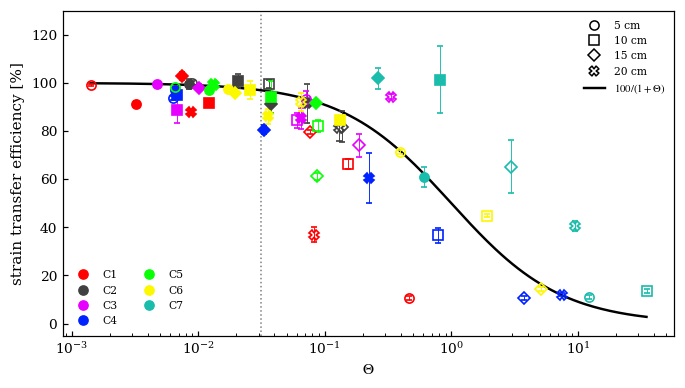

In [2]:
d = load_results('freqdomain_eta')

fig, ax = paper.paper_figure(width='full', height=3.6)

theta = d['theta_sag']
eta = d['eta_h1'] * 100.0
eta_std = d['eta_h1_std'] * 100.0

for i in range(len(d['labels'])):
    col = CABLE_COLORS.get(str(d['cable'][i]), 'gray')
    marker = GAP_MARKERS.get(round(float(d['gap_m'][i]), 2), 's')
    open_marker = bool(d['is_sag_variant'][i])
    ax.errorbar(theta[i], eta[i], yerr=eta_std[i],
                marker=marker, ms=6, ls='none', color=col,
                mfc='none' if open_marker else col, mew=1.1,
                elinewidth=0.6, capsize=2, zorder=3)

x_th = np.logspace(np.log10(max(theta.min(), 1e-6)), np.log10(theta.max()), 200)
ax.plot(x_th, 100.0 / (1.0 + x_th), 'k-', lw=1.6, zorder=2)
ax.axvline(1/32, color='gray', ls=':', lw=1.0, zorder=1)

paper.style_axis(ax, xlabel=r'$\Theta$',
                 ylabel='strain transfer efficiency [%]',
                 xscale='log', ylim=(-5, 130))

cable_handles = [Line2D([0], [0], marker='o', ls='none', color=c, ms=6,
                        label=n) for n, c in CABLE_COLORS.items()]
gap_handles = [Line2D([0], [0], marker=m, ls='none', color='k', mfc='none',
                      ms=6, label=f'{int(g*100)} cm')
               for g, m in GAP_MARKERS.items()]
extra = [Line2D([0], [0], color='k', lw=1.6, label=r'$100/(1+\Theta)$')]
leg1 = ax.legend(handles=cable_handles, fontsize=7, loc='lower left',
                 frameon=False, ncol=2)
ax.add_artist(leg1)
ax.legend(handles=gap_handles + extra, fontsize=7, loc='upper right',
          frameon=False)

paper.save_paper_fig(fig, 'eta_vs_theta')
paper.caption_note(
    f"Measured quasi-static strain-transfer efficiency (band "
    f"{d['meta']['band'][0]:.0f}-{d['meta']['band'][1]:.0f} Hz, coherence-"
    f"gated H1 estimate) against the sag parameter Theta, with the "
    f"analytical prediction 1/(1+Theta).")

---
## Fig. B — Strain-transfer FRF (four-panel, wrapped phase)

Rebuilt from the exported FRF curves of the datasets selected in notebook 03
§ 1. Low-coherence bins are drawn faint.

c:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\Experiment2\Analysis_v2\ldv_analysis\paper.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved: frf_four_panel.png, frf_four_panel.pdf
[caption] Measured FRFs: midpoint bending response (a, b) and strain transfer (c, d); wrapped phase; faint = coherence below the gate; dotted verticals = identified resonance f1; dashed = quasi-static 1/(1+Theta).


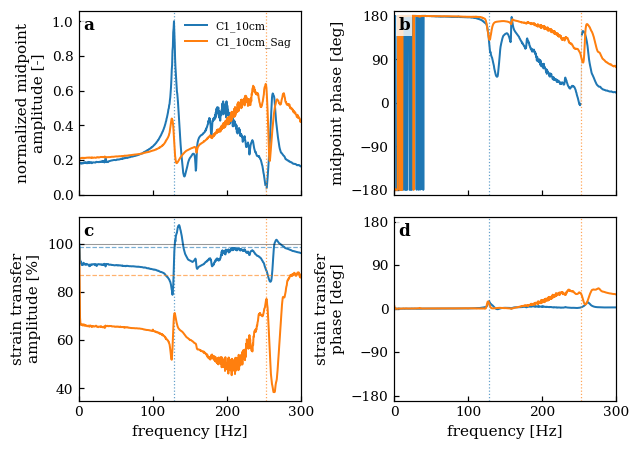

In [3]:
d = load_results('freqdomain_frf')
COH_GATE = d['meta'].get('coh_thresh', 0.7)
F_MAX = 300.0                      # <- x-limit control

f = d['f']
band = (f > 0) & (f <= F_MAX)
fb = f[band]

fig, axes = paper.paper_figure(2, 2, width='full', height=4.6, sharex=True,
                               gridspec_kw={'hspace': 0.12, 'wspace': 0.42})
(ax_a, ax_b), (ax_c, ax_d) = axes

norm = np.nanmax(d['H_mid_abs'][:, band])
for i, lbl in enumerate(d['labels']):
    col = 'C%d' % (i % 10)
    good_m = d['coh_mid'][i, band] >= COH_GATE
    good_e = d['coh_eta'][i, band] >= COH_GATE

    amp_m = d['H_mid_abs'][i, band] / norm
    ax_a.plot(fb, amp_m, color='0.85', lw=0.6)
    ax_a.plot(fb, np.where(good_m, amp_m, np.nan), color=col, lw=1.3,
              label=str(lbl))

    ph_m = np.degrees(d['H_mid_phase'][i, band])
    ax_b.plot(fb, ph_m, color='0.85', lw=0.6)
    ax_b.plot(fb, np.where(good_m, ph_m, np.nan), color=col, lw=1.3)

    amp_e = d['H_eta_abs'][i, band] * 100.0
    ax_c.plot(fb, amp_e, color='0.85', lw=0.6)
    ax_c.plot(fb, np.where(good_e, amp_e, np.nan), color=col, lw=1.3)
    ax_c.axhline(d['eta_pred'][i] * 100.0, color=col, ls='--', lw=0.8,
                 alpha=0.6)

    ph_e = np.degrees(d['H_eta_phase'][i, band])
    ax_d.plot(fb, ph_e, color='0.85', lw=0.6)
    ax_d.plot(fb, np.where(good_e, ph_e, np.nan), color=col, lw=1.3)

    if d['f1_meas'][i] <= F_MAX:
        for ax in (ax_a, ax_b, ax_c, ax_d):
            ax.axvline(d['f1_meas'][i], color=col, ls=':', lw=0.8, alpha=0.7)

ax_c.axhline(100, color='k', lw=0.7, alpha=0.4)
paper.style_axis(ax_a, ylabel='normalized midpoint\namplitude [-]',
                 xlim=(0, F_MAX), ylim=(0, 1.06))
paper.style_axis(ax_b, ylabel='midpoint phase [deg]', ylim=(-190, 190))
paper.style_axis(ax_c, xlabel='frequency [Hz]',
                 ylabel='strain transfer\namplitude [%]')
paper.style_axis(ax_d, xlabel='frequency [Hz]',
                 ylabel='strain transfer\nphase [deg]', ylim=(-190, 190))
for ax, letter in zip((ax_a, ax_b, ax_c, ax_d), 'abcd'):
    paper.panel_label(ax, letter, boxed=True)
ax_a.legend(fontsize=7, frameon=False, loc='upper right')
for ax in (ax_b, ax_d):
    ax.set_yticks([-180, -90, 0, 90, 180])

paper.save_paper_fig(fig, 'frf_four_panel')
paper.caption_note(
    'Measured FRFs: midpoint bending response (a, b) and strain transfer '
    '(c, d); wrapped phase; faint = coherence below the gate; dotted '
    'verticals = identified resonance f1; dashed = quasi-static 1/(1+Theta).')

---
## Fig. C — FRF estimator comparison (H1 / H2 / Hv / coherence)

Processing-chapter figure: the estimators only separate where the coherence
drops.

saved: estimator_comparison.png, estimator_comparison.pdf
[caption] FRF estimator comparison for C1_10cm: H1, H2 and Hv bracket the true FRF; their separation grows where the coherence (bottom) drops.


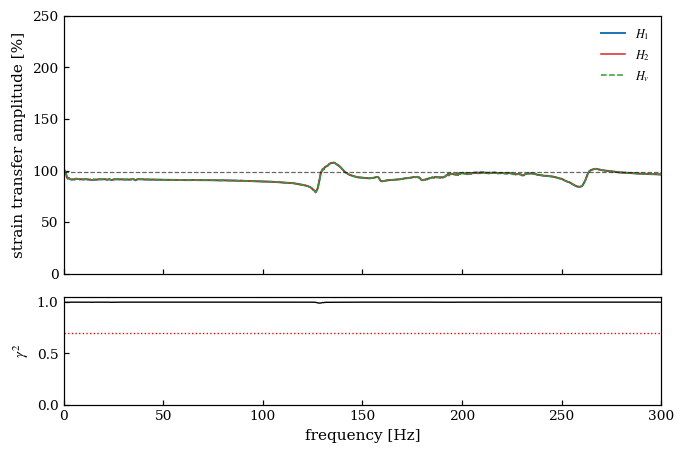

In [4]:
d = load_results('freqdomain_frf')
IDX = 0                                   # dataset row in the export
F_MAX = 300.0

f = d['f']
band = (f > 0) & (f <= F_MAX)
fb = f[band]

fig, (ax1, ax2) = paper.paper_figure(2, 1, width='full', height=4.2,
                                     sharex=True,
                                     gridspec_kw={'height_ratios': [2.4, 1.0]})
ax1.plot(fb, d['H_eta_abs'][IDX, band] * 100, color='C0', lw=1.3,
         label=r'$H_1$')
ax1.plot(fb, d['H_eta_h2_abs'][IDX, band] * 100, color='C3', lw=1.0,
         label=r'$H_2$')
ax1.plot(fb, d['H_eta_hv_abs'][IDX, band] * 100, color='C2', lw=1.0, ls='--',
         label=r'$H_v$')
ax1.axhline(d['eta_pred'][IDX] * 100, color='k', ls='--', lw=0.8, alpha=0.6)
ax2.plot(fb, d['coh_eta'][IDX, band], color='k', lw=0.9)
ax2.axhline(0.7, color='r', ls=':', lw=0.9)

paper.style_axis(ax1, ylabel='strain transfer amplitude [%]',
                 ylim=(0, 250), legend=True)
paper.style_axis(ax2, xlabel='frequency [Hz]', ylabel=r'$\gamma^2$',
                 xlim=(0, F_MAX), ylim=(0, 1.05))

paper.save_paper_fig(fig, 'estimator_comparison')
paper.caption_note(
    f"FRF estimator comparison for {d['labels'][IDX]}: H1, H2 and Hv "
    'bracket the true FRF; their separation grows where the coherence '
    '(bottom) drops.')

---
## Fig. D — Measured vs theoretical sag

saved: sag_measured_vs_theory.png, sag_measured_vs_theory.pdf
[caption] Measured midpoint sag (parabola fit; error bars = RMS fit residual) against the tension-free analytical sag rho*A*g*L^4/(4 pi^4 EI). Points below the 1:1 line indicate residual pretension.


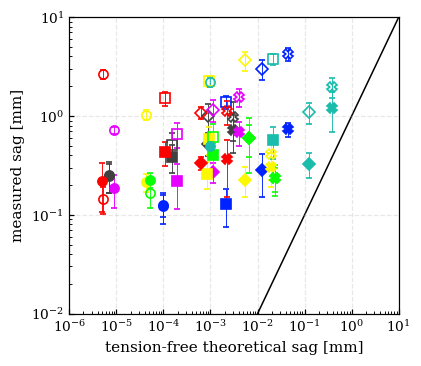

In [11]:
d = load_results('geometry_sag')

fig, ax = paper.paper_figure(width='half', height=3.4)

for i in range(len(d['labels'])):
    col = CABLE_COLORS.get(str(d['cable'][i]), 'gray')
    marker = GAP_MARKERS.get(round(float(d['gap_m'][i]), 2), 's')
    open_marker = bool(d['is_sag_variant'][i])
    ax.errorbar(d['sag_theory_tension_free'][i] * 1e3, d['sag'][i] * 1e3,
                yerr=d['sag_rms_residual'][i] * 1e3,
                marker=marker, ms=6, ls='none', color=col,
                mfc='none' if open_marker else col, mew=1.1,
                elinewidth=0.6, capsize=2, zorder=3)

lims = np.array([1e-6, 1e2])
ax.plot(lims, lims, 'k-', lw=1.0, zorder=1)
paper.style_axis(ax, xlabel='tension-free theoretical sag [mm]',
                 ylabel='measured sag [mm]',
                 xscale='log', yscale='log',
                 xlim=(1e-6, 1e1), ylim=(1e-2, 1e1))
ax.grid()

paper.save_paper_fig(fig, 'sag_measured_vs_theory')
paper.caption_note(
    'Measured midpoint sag (parabola fit; error bars = RMS fit residual) '
    'against the tension-free analytical sag rho*A*g*L^4/(4 pi^4 EI). '
    'Points below the 1:1 line indicate residual pretension.')

---
## Fig. E — Time-domain example window

How η is measured: reference elongation vs cable elongation (three strain
methods) in one ±N-cycle window.

saved: timedomain_example_window.png, timedomain_example_window.pdf
[caption] Example window (C1_20cm, 30 Hz, bandpass 25.0-35.0 Hz): (a) reference elongation and cable elongation from the three strain methods; (b) instantaneous efficiency and its median.


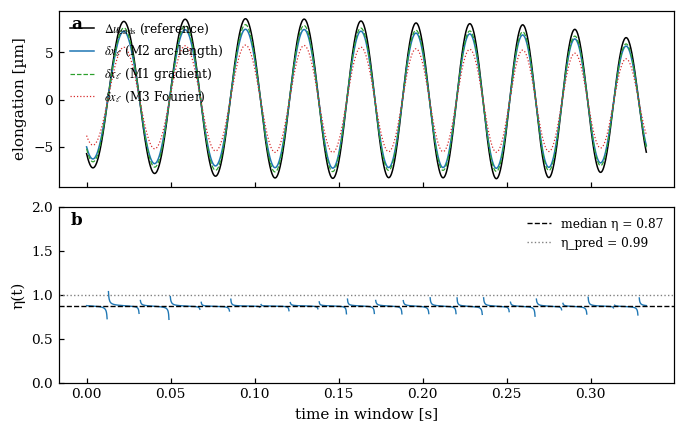

In [12]:
d = load_results('timedomain_example')
meta = d['meta']

fig, (ax1, ax2) = paper.paper_figure(2, 1, width='full', height=4.0,
                                     sharex=True)
t = d['t'] - d['t'][0]
ax1.plot(t, d['delta_ends'] * 1e6, color='k', lw=1.0,
         label=r'$\Delta u_\mathrm{ends}$ (reference)')
ax1.plot(t, d['delta_xl_m2'] * 1e6, color='C0', lw=1.0,
         label=r'$\delta x_\ell$ (M2 arc-length)')
ax1.plot(t, d['delta_xl_m1'] * 1e6, color='C2', lw=0.8, ls='--',
         label=r'$\delta x_\ell$ (M1 gradient)')
ax1.plot(t, d['delta_xl_m3'] * 1e6, color='C3', lw=0.8, ls=':',
         label=r'$\delta x_\ell$ (M3 Fourier)')

ax2.plot(t, d['eta_t_ends'], color='C0', lw=0.9)
ax2.axhline(meta['eta_med_ends'], color='k', ls='--', lw=0.9,
            label=f"median η = {meta['eta_med_ends']:.2f}")
ax2.axhline(meta['eta_pred'], color='gray', ls=':', lw=0.9,
            label=f"η_pred = {meta['eta_pred']:.2f}")

paper.style_axis(ax1, ylabel='elongation [µm]', legend=True)
paper.style_axis(ax2, xlabel='time in window [s]', ylabel='η(t)',
                 ylim=(0, 2), legend=True)
paper.panel_label(ax1, 'a'); paper.panel_label(ax2, 'b')

paper.save_paper_fig(fig, 'timedomain_example_window')
paper.caption_note(
    f"Example window ({meta['label']}, {meta['f_target']} Hz, bandpass "
    f"{meta['f_lo']:.1f}-{meta['f_hi']:.1f} Hz): (a) reference elongation "
    'and cable elongation from the three strain methods; (b) instantaneous '
    'efficiency and its median.')

---
## Fig. F — Amplitude overview (endpoint strain, band mean)

saved: amplitude_strain_overview.png, amplitude_strain_overview.pdf
[caption] Band-mean endpoint strain (1-25 Hz) per configuration; error bars = std across band frequencies.


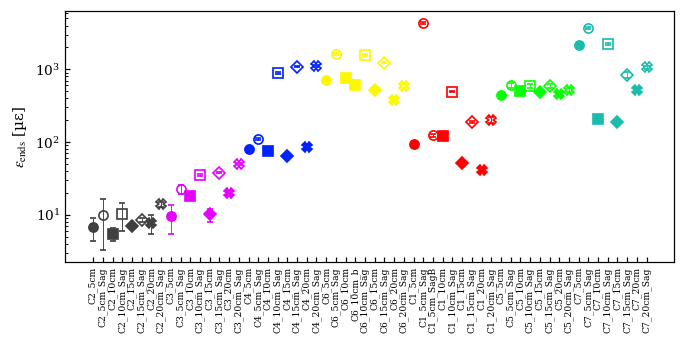

In [16]:
d = load_results('amplitude_reference')
f = d['f']
FMIN, FMAX = d['meta']['band']
m = (f >= FMIN) & (f <= FMAX)

fig, ax = paper.paper_figure(width='full', height=3.2)
for i in range(len(d['labels'])):
    col = CABLE_COLORS.get(str(d['cable'][i]), 'gray')
    marker = GAP_MARKERS.get(round(float(d['gap_m'][i]), 2), 's')
    open_marker = bool(d['is_sag_variant'][i])
    vals = d['strain_ends'][i, m] * 1e6
    ax.errorbar(i, np.nanmean(vals), yerr=np.nanstd(vals),
                marker=marker, ms=6, ls='none', color=col,
                mfc='none' if open_marker else col, mew=1.1,
                elinewidth=0.6, capsize=2)
ax.set_xticks(range(len(d['labels'])))
ax.set_xticklabels([str(l) for l in d['labels']], rotation=90, fontsize=6)
paper.style_axis(ax, ylabel=r'$\varepsilon_\mathrm{ends}$ [µε]',
                 yscale='log')

paper.save_paper_fig(fig, 'amplitude_strain_overview')
paper.caption_note(
    f'Band-mean endpoint strain ({FMIN:.0f}-{FMAX:.0f} Hz) per '
    'configuration; error bars = std across band frequencies.')

---
### Template for further figures

Copy a cell above and swap the export file / keys. The pattern is always:

```python
d = load_results('<name>')                       # arrays + d['meta']
fig, ax = paper.paper_figure(width=..., height=...)
# ... plot ...
paper.style_axis(ax, xlabel=..., ylabel=..., xlim=..., ylim=...)
paper.save_paper_fig(fig, '<figure_name>')
paper.caption_note('...caption draft for the thesis...')
```